# Argus — CNN Training (Face Crops)

A small CNN trained directly on cropped RGB face images — no hand-engineered features at all.
Like `04_random_forest_training.ipynb` and `05_dense_nn_training.ipynb`, this is a single-image-
in, single-label-out model: one cropped face predicts one drowsiness level, no sequence, no
buffer across frames.

**Reads:** `dataset_processed/face_crops_index.csv` and the `.jpg` files it points to, written by
[`06_dataset_creation_face_crops.ipynb`](./06_dataset_creation_face_crops.ipynb) — run that first.

**Writes:** `models/cnn_face_crops_<VERSION>.keras`.

**Why "tiny."** The other three model families (LSTM, RandomForest, Dense NN) all work from a
59-dimensional-or-smaller hand-engineered feature vector. This model instead has to learn visual
features from raw pixels, which is a fundamentally harder learning problem to solve from the
amount of data this project has (tens of subjects, not the thousands a large vision model would
want) — so the architecture below is deliberately small and heavily regularized (few conv
blocks, dropout, no pretrained backbone) rather than a scaled-up architecture that would likely
just overfit. This is also the only model family with a plausible path to running its own
inference directly on cropped camera frames without the geometric-feature pipeline at all, which
is worth noting for the titulación report as a architectural alternative, even though the project
is standardizing on the LSTM for deployment (see `03_model_training_lstm.ipynb`'s Design
Decision cell) — this notebook exists to have that comparison on record, not to replace it.


## Setup

Mounts Drive, defines the paths this notebook needs, loads `face_crops_index.csv`, and
initializes model-versioning config. Independent of any other notebook's in-memory state — only
depends on `face_crops_index.csv` and the images it references.


In [1]:
from google.colab import drive
import os
import datetime
import pandas as pd

drive.mount('/content/drive')

# --- Argus project paths (must match 06_dataset_creation_face_crops.ipynb) ---
project_folder = "/content/drive/MyDrive/Argus"
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
face_crops_index_csv_path = os.path.join(processed_folder, "face_crops_index.csv")

if not os.path.exists(face_crops_index_csv_path):
    raise FileNotFoundError(
        f"'{face_crops_index_csv_path}' not found. Run 06_dataset_creation_face_crops.ipynb "
        "first — this notebook only reads the dataset it produces, it doesn't build it."
    )

df_face_crops = pd.read_csv(face_crops_index_csv_path)
print(f"Loaded face crop index: {len(df_face_crops)} images, "
      f"{df_face_crops['subject'].nunique()} subjects.")

# --- Model Management Configuration ---
FORCE_RETRAIN = True
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
# Two model paths -- this notebook now trains two 3-class variants (a from-scratch CNN and a
# MobileNetV2-backed one) side by side for comparison, not just one.
cnn_scratch_model_path = os.path.join(models_folder, f"cnn_face_crops_scratch_{VERSION_STR}.keras")
cnn_mobilenet_model_path = os.path.join(models_folder, f"cnn_face_crops_mobilenet_{VERSION_STR}.keras")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


Mounted at /content/drive
Loaded face crop index: 3751 images, 24 subjects.
✅ Model management initialized. Current version: 20260824_0308. Force retrain: True


## Splitting the Dataset

Group-aware split by subject, same rationale as every other notebook: crops from the same clip
are highly correlated (near-duplicate faces a few frames apart), so a plain random split would
leak near-duplicates across train/test and inflate reported accuracy.

Not every subject currently has all 3 classes (dataset extraction is still catching up on some
subjects — see `06_dataset_creation_face_crops.ipynb`'s per-subject completeness check). Those
subjects are **not excluded from the dataset** — they still contribute real training examples for
whichever classes they do have — but they're excluded from **test-fold eligibility**: only
subjects with all 3 classes present can be chosen as held-out test subjects. This guarantees the
test fold always has every class represented, since `StratifiedGroupKFold` can only balance
classes across whatever data actually exists — it can't invent a class a subject never recorded.

The split happens on the **index CSV** (file paths + labels), before any image is decoded — the
actual pixel loading happens lazily in the `tf.data` pipeline below.


In [2]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

# Only subjects with all 3 classes present are eligible to be picked as *test* subjects.
# Incomplete subjects (missing a class entirely) are NOT dropped from the dataset -- they're
# still valid training data for whichever classes they have -- they're just never candidates for
# the held-out fold, since a test fold drawn from them could be missing a class no matter how the
# split algorithm balances things (it can only work with what a subject actually recorded).
subject_level_sets = df_face_crops.groupby('subject')['level'].agg(set)
complete_subjects = subject_level_sets[subject_level_sets == {1, 2, 3}].index
incomplete_subjects = subject_level_sets.index.difference(complete_subjects)

if len(complete_subjects) < 2:
    raise ValueError(
        f"Only {len(complete_subjects)} subject(s) have all 3 classes ({list(complete_subjects)}) "
        "-- need at least 2 to hold one out for testing. Finish dataset extraction "
        "(06_dataset_creation_face_crops.ipynb) for more subjects before training."
    )

print(f"{len(complete_subjects)} complete subject(s) eligible for testing: {sorted(complete_subjects)}")
if len(incomplete_subjects) > 0:
    print(f"{len(incomplete_subjects)} incomplete subject(s) reserved for validation (missing a "
          f"class, so ineligible for the held-out test fold): {sorted(incomplete_subjects)}")

# Test fold selection only ever looks at complete subjects.
df_complete = df_face_crops[df_face_crops['subject'].isin(complete_subjects)]
N_SPLITS = min(5, len(complete_subjects))
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
_, complete_test_pos = next(sgkf.split(df_complete, df_complete['level'], groups=df_complete['subject']))
test_subjects = set(df_complete.iloc[complete_test_pos]['subject'])

# Validation = the incomplete-subject pool. Genuinely held out and structurally incapable of
# leaking into test-fold selection (it was never part of df_complete). This replaces the old
# validation_data=test_ds wiring, under which EarlyStopping/ModelCheckpoint/ReduceLROnPlateau
# were all implicitly selecting checkpoints on the test set itself -- the reported "test" metric
# was the same number the training loop had already been optimizing against, not a real holdout.
val_subjects = set(incomplete_subjects)

test_mask = df_face_crops['subject'].isin(test_subjects)
val_mask = df_face_crops['subject'].isin(val_subjects)
train_mask = ~test_mask & ~val_mask

df_train = df_face_crops[train_mask].reset_index(drop=True)
df_val = df_face_crops[val_mask].reset_index(drop=True)
df_test = df_face_crops[test_mask].reset_index(drop=True)

if len(df_val) == 0:
    raise ValueError(
        "No incomplete subjects available to build a validation set. Either every subject has "
        "all 3 classes (pick one complete subject out of the train pool manually instead) or "
        "the dataset changed shape -- don't silently fall back to validation_data=test_ds."
    )

print(f"\nTrain: {len(df_train)} crops ({df_train['subject'].nunique()} subjects)")
print(f"Val:   {len(df_val)} crops ({df_val['subject'].nunique()} subjects, incomplete -- may not "
      f"cover all 3 classes individually, but should collectively)")
print(f"Test:  {len(df_test)} crops ({df_test['subject'].nunique()} subjects, all complete)")
print("\nPer-class support:")
print("  Train:", df_train['level'].value_counts().sort_index().to_dict())
print("  Val:  ", df_val['level'].value_counts().sort_index().to_dict())
print("  Test: ", df_test['level'].value_counts().sort_index().to_dict())

missing_in_test = set(df_face_crops['level'].unique()) - set(df_test['level'].unique())
if missing_in_test:
    raise ValueError(f"Test fold missing level(s) {sorted(missing_in_test)} -- treat as a bug.")

missing_in_val = set(df_face_crops['level'].unique()) - set(df_val['level'].unique())
if missing_in_val:
    print(f"⚠️  Val fold is missing level(s) {sorted(missing_in_val)} -- macro-F1 callbacks below "
          f"pass explicit labels=[0,1,2] so this doesn't silently distort the metric, but a class "
          f"with zero val examples still can't validate that class's generalization this run.")


20 complete subject(s) eligible for testing: ['subject_03', 'subject_04', 'subject_07', 'subject_08', 'subject_09', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_15', 'subject_16', 'subject_17', 'subject_18', 'subject_19', 'subject_20', 'subject_21', 'subject_22', 'subject_23', 'subject_24']
4 incomplete subject(s) reserved for validation (missing a class, so ineligible for the held-out test fold): ['subject_01', 'subject_02', 'subject_05', 'subject_06']

Train: 2830 crops (16 subjects)
Val:   201 crops (4 subjects, incomplete -- may not cover all 3 classes individually, but should collectively)
Test:  720 crops (4 subjects, all complete)

Per-class support:
  Train: {1: 920, 2: 960, 3: 950}
  Val:   {1: 60, 2: 91, 3: 50}
  Test:  {1: 240, 2: 240, 3: 240}


## Building the `tf.data` Pipeline

Crops are variable-size (see `06_dataset_creation_face_crops.ipynb`), so every image is resized
to a fixed `IMG_SIZE x IMG_SIZE` here. `IMG_SIZE = 96` is chosen as a small-but-workable input
resolution for a *tiny* CNN — large enough to keep eye/mouth detail legible after the face
detector's crop, small enough to keep the model and its memory footprint modest. Pixel scaling
(`1/255`) is done as a `Rescaling` layer inside the model itself (see the model definition below)
rather than as a separate `StandardScaler` artifact, so the trained `.keras` file is a fully
self-contained image-in, prediction-out artifact with no companion scaler file to keep in sync.


In [3]:
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 32
CLASS_NAMES = ['Alert', 'Low Vigilant', 'Drowsy']

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# Augmentation beyond plain flip+brightness: the first training run reached >99% train accuracy
# within 2 epochs on a 28K-param model trained over only 4 subjects -- a strong sign it was keying
# on subject identity (skin tone, lighting, background) rather than drowsiness cues, which a
# held-out subject's face doesn't share. Small rotation/zoom/contrast jitter make that identity
# shortcut harder to exploit while staying mild enough not to distort the drowsiness-relevant
# eye/mouth region the way aggressive geometric augmentation would.
geometric_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # ~+/-18 degrees
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

def make_dataset(df, training: bool):
    paths = df['image_path'].to_numpy()
    labels = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Alert, 1=Low Vigilant, 2=Drowsy
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (tf.image.random_brightness(img, max_delta=0.15), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (geometric_augmenter(img, training=True), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(df_train, training=True)
val_ds = make_dataset(df_val, training=False)
test_ds = make_dataset(df_test, training=False)

print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}")


IMG_SIZE=96, BATCH_SIZE=32


## Tiny CNN Model Definition

Three convolutional blocks (`Conv2D -> BatchNorm -> MaxPool`), increasing filter count, followed
by `GlobalAveragePooling2D` (instead of `Flatten` + a large `Dense` layer, to keep parameter
count down and reduce overfitting risk) and a small classification head.


In [4]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout,
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

num_classes = len(CLASS_NAMES)

def build_cnn_scratch(num_classes=num_classes):
    """Original from-scratch tiny CNN -- architecture unchanged. num_classes is a parameter
    (not hardcoded to 3) so this same builder can also produce the 2-class Low-Vigilant-vs-Drowsy
    head further down, without duplicating the conv stack."""
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Rescaling(1. / 255),

        Conv2D(16, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        GlobalAveragePooling2D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.4),
        Dense(num_classes, activation='softmax'),
    ], name='cnn_scratch')
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def build_mobilenet_backbone(alpha=0.35, trainable_backbone=False):
    """MobileNetV2 pretrained on ImageNet as a feature extractor, with a small trainable head.

    alpha=0.35 (the smallest official MobileNetV2 width multiplier) is used for consistency with
    this project's eventual edge-deployment goal (Raspberry Pi), not to maximize accuracy --
    alpha=1.0 (standard/full-capacity) is the alternative if this underfits.

    MobileNetV2 expects inputs scaled to [-1, 1] via `preprocess_input`, not the [0, 1] scaling
    the scratch CNN uses -- that preprocessing lives *inside this model*, applied to the raw
    [0, 255] pixels the shared tf.data pipeline already produces (see the cell above), so
    train_ds/val_ds/test_ds stay identical, unmodified for both variants; nothing forks upstream.

    Honest trade-off, untested in this project so far: a frozen backbone can't memorize subject
    identity via gradient updates the way the from-scratch model has been shown to (>99% train
    accuracy while val stayed noisy/low) -- that directly targets the overfitting pattern. But
    ImageNet features may not represent drowsiness-specific cues (eye-closure duration proxies,
    subtle redness) well. Not a guaranteed win over the from-scratch model -- that's exactly what
    this A/B comparison is for.
    """
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=alpha,
                        include_top=False, weights='imagenet')
    base.trainable = trainable_backbone

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_input(inputs)     # [0,255] -> [-1,1]; replaces Rescaling(1/255)
    x = base(x, training=False)      # keeps BatchNorm stats frozen even if unfrozen later
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name='mobilenet_v2_backbone')

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


## CNN Model Training

`class_weight`, computed from the training set's actual label distribution, for the same reason
as every other model here: `Drowsy` is plausibly the rarest class and the most safety-critical
one to not neglect.


In [11]:
model_scratch = build_cnn_scratch()
model_scratch.summary()


Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,387 (110.89 KB)

 Trainable params: 28,163 (110.01 KB)

 Non-trainable params: 224 (896.00 B)

In [12]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

class MacroF1Callback(Callback):
    """Adds `val_macro_f1` to the epoch's `logs` dict so EarlyStopping/ModelCheckpoint below can
    select on it instead of raw accuracy. Raw val_accuracy is not a safe selection metric under
    class imbalance -- it's exactly what let a model that always predicted the majority class
    look like an 84.75%-accurate model in the first run of this notebook, while missing every
    single Drowsy case (0.00 recall). Runs one extra prediction pass over the validation set per
    epoch; negligible cost at this model/dataset size.

    Passes explicit labels=[0..num_classes-1]: df_val (the incomplete-subject pool) isn't
    guaranteed to cover every class every run, and without explicit labels sklearn infers them
    from whatever's present in that epoch's val predictions -- silently changing what "macro-F1"
    means run to run instead of comparing the same fixed set of classes throughout training.
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true = np.concatenate([y.numpy() for _, y in self.val_ds])
        y_pred = np.argmax(self.model.predict(self.val_ds, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(y_true, y_pred, average='macro',
                                         labels=list(range(num_classes)), zero_division=0)

# Class weights computed ONCE here, reused unchanged for the MobileNetV2 variant below -- the
# only thing that differs between the two training runs is architecture, not class balancing.
train_labels = (df_train['level'].to_numpy(dtype=np.int32) - 1)
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weight_dict = dict(zip(np.unique(train_labels).tolist(), weights))

# Drowsy is the safety-critical class and had the worst recall (0.27) in the last evaluated run.
# 2x its already-balanced weight so misclassifying a real Drowsy frame costs the loss more than
# plain inverse-frequency weighting alone. Tune this constant down if it overcorrects into
# hurting Alert/Low Vigilant precision too much.
DROWSY_LABEL = CLASS_NAMES.index('Drowsy')  # 2
DROWSY_WEIGHT_BOOST = 2.0
weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
print(f"Class weights (Drowsy boosted {DROWSY_WEIGHT_BOOST}x): {weight_dict}")

# EarlyStopping and ModelCheckpoint both monitor val_macro_f1 -- they used to watch val_loss and
# val_accuracy respectively, two different "best" epochs that could (and did) diverge.
# macro_f1_cb must run first in this list so it populates logs['val_macro_f1'] before the other
# two callbacks read it within the same epoch.
#
# All three callbacks watch val_ds (the fixed incomplete-subject pool from the split cell), NOT
# test_ds. Previously validation_data=test_ds meant every training-time decision -- early
# stopping, which epoch gets checkpointed, the LR-plateau schedule -- was made by watching the
# exact same held-out subject that the eval cell reports the final test number on. There was no
# independent check at all. test_ds is now only ever touched in the evaluation cell below, after
# training is completely finished.
macro_f1_cb_scratch = MacroF1Callback(val_ds)
early_stopping_scratch = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
checkpoint_scratch = ModelCheckpoint(filepath=os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras'),
                                      monitor='val_macro_f1', mode='max', save_best_only=True)
reduce_lr_scratch = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training scratch CNN...")
history_scratch = model_scratch.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_scratch, early_stopping_scratch, checkpoint_scratch, reduce_lr_scratch],
    class_weight=weight_dict,
    verbose=1,
)

model_scratch.save(cnn_scratch_model_path)
print(f"💾 Model saved: {cnn_scratch_model_path}")


Class weights (Drowsy boosted 2.0x): {0: np.float64(1.0253623188405796), 1: np.float64(0.9826388888888888), 2: np.float64(1.9859649122807017)}
🚀 Training scratch CNN...
Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.5329 - loss: 1.2320 - val_accuracy: 0.2488 - val_loss: 1.2131 - val_macro_f1: 0.1328 - learning_rate: 0.0010
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6894 - loss: 0.9084 - val_accuracy: 0.2488 - val_loss: 1.8604 - val_macro_f1: 0.1328 - learning_rate: 0.0010
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7657 - loss: 0.7452 - val_accuracy: 0.2537 - val_loss: 2.4524 - val_macro_f1: 0.1443 - learning_rate: 0.0010
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8329 - loss: 0.5793 - val_accuracy: 0.2438 - val_loss: 2.2744 - val_macro_f1: 0.1932 - learning_rate: 0.0010
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8682 - loss: 0.4844 - val_accuracy: 0.5224 - val_loss: 2.0035 - 

In [13]:
!ls -lh {models_folder}

total 945M
-rw------- 1 root root 397K Aug 24 00:26 best_cnn_face_crops.keras
-rw------- 1 root root 397K Aug 24 03:17 best_cnn_scratch_face_crops.keras
-rw------- 1 root root 235K Aug 19 01:31 best_dense_nn.keras
-rw------- 1 root root 904K Aug 18 01:46 best_lstm_model.keras
-rw------- 1 root root 225K Aug 18 22:21 blaze_face_short_range.tflite
-rw------- 1 root root 397K Aug 23 02:54 cnn_face_crops_20260823_0242.keras
-rw------- 1 root root 397K Aug 23 21:41 cnn_face_crops_20260823_2138.keras
-rw------- 1 root root 397K Aug 24 00:27 cnn_face_crops_20260824_0020.keras
-rw------- 1 root root 397K Aug 24 03:17 cnn_face_crops_scratch_20260824_0308.keras
-rw------- 1 root root 2.0K Aug 19 00:29 dense_feature_scaler_20260819_0029.joblib
-rw------- 1 root root 2.0K Aug 19 00:38 dense_feature_scaler_20260819_0038.joblib
-rw------- 1 root root 2.0K Aug 19 01:29 dense_feature_scaler_20260819_0129.joblib
-rw------- 1 root root 235K Aug 19 00:31 dense_nn_20260819_0029.keras
-rw------- 1 root roo

## CNN Model Evaluation


Loading best scratch model from /content/drive/MyDrive/Argus/models/best_cnn_scratch_face_crops.keras...

CNN Test Loss: 5.8055
CNN Test Accuracy: 0.3153
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
CNN Test Macro-F1: 0.3298

Classification Report (CNN - Best Checkpoint):
              precision    recall  f1-score   support

       Alert       0.19      0.28      0.23       240
Low Vigilant       0.29      0.25      0.27       240
      Drowsy       0.60      0.42      0.50       240

    accuracy                           0.32       720
   macro avg       0.36      0.32      0.33       720
weighted avg       0.36      0.32      0.33       720



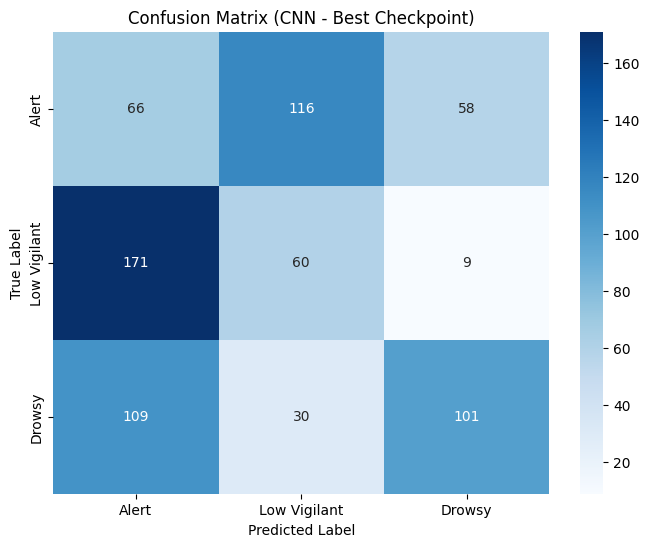

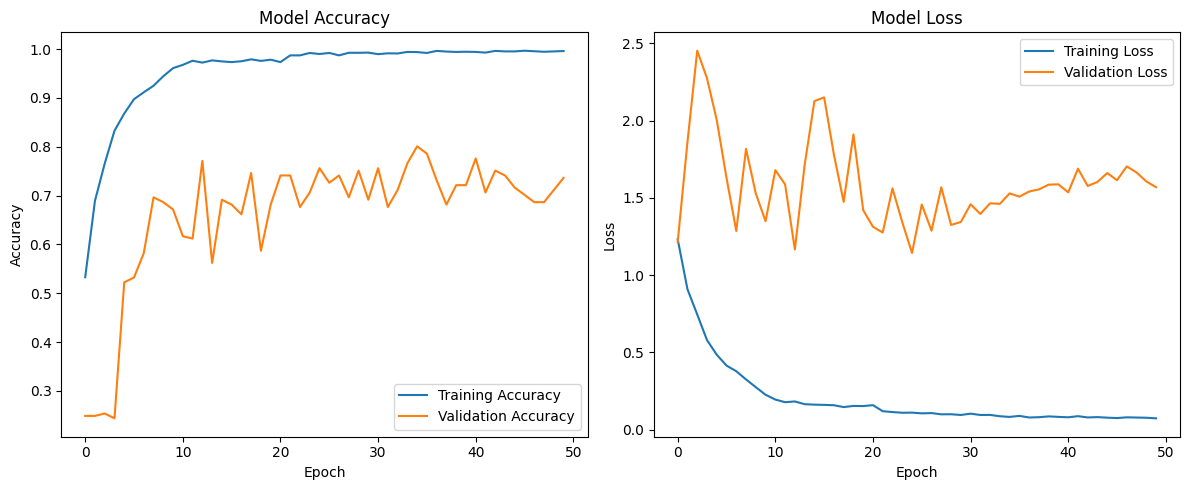

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

# Load the best saved checkpoint for evaluation
best_scratch_path = os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras')
if os.path.exists(best_scratch_path):
    print(f"Loading best scratch model from {best_scratch_path}...")
    model_eval = tf.keras.models.load_model(best_scratch_path)
else:
    print("Best checkpoint not found, falling back to in-memory model.")
    model_eval = model_scratch

loss, accuracy = model_eval.evaluate(test_ds, verbose=0)
print(f"\nCNN Test Loss: {loss:.4f}")
print(f"CNN Test Accuracy: {accuracy:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = model_eval.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Macro-F1 (unweighted mean of per-class F1) alongside accuracy
print(f"CNN Test Macro-F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

print("\nClassification Report (CNN - Best Checkpoint):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (CNN - Best Checkpoint)')
plt.show()

# Note: Plotting history still uses the last run's training session object
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Training Loss')
plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Reading this result alongside the other models

This model has strictly less information available per prediction than the geometric-feature
models — it never sees EAR/MAR/blendshapes/pose directly, only pixels, and has to (re-)learn
whatever of that signal it can from a comparatively small image dataset. Treat any accuracy gap
against RandomForest/Dense NN as evidence about how hard that visual-feature-learning problem is
from this dataset's size, not as a verdict on face-crop CNNs as an approach in general — a much
larger face dataset (or a pretrained backbone) would likely close much of that gap, neither of
which this project's data budget currently supports.
